
# Federal Reserve Economic Dashboard (Project for IBM Exploratory Data Analysis for Machine Learning)

### A Macro-Finance Research Report Using FRED Data

**Research Question:**  
How do monetary policy, inflation, financial markets, and real economic activity interact in the U.S. economy?

## Setup

In [10]:

# Install (if needed)
# !pip install pandas numpy matplotlib scipy scikit-learn statsmodels pandas_datareader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas_datareader import data as web
from scipy.stats import pearsonr, ttest_ind

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

plt.style.use("ggplot")


## Data Collection (FRED)

In [11]:

start, end = "2000-01-01", "2024-12-31"

series = {
    "FedFunds": "FEDFUNDS",
    "CPI": "CPIAUCSL",
    "CoreCPI": "CPILFESL",
    "Unemployment": "UNRATE",
    "GDP": "GDPC1",
    "Treasury10Y": "GS10",
    "M2": "M2SL",
    "IndustrialProduction": "INDPRO",
    "ConsumerSentiment": "UMCSENT",
    "Recession": "USREC"
}

df = pd.concat(
    [web.DataReader(v, "fred", start, end).rename(columns={v:k}) for k,v in series.items()],
    axis=1
).ffill()

df.head()


,FedFunds,CPI,CoreCPI,Unemployment,GDP,Treasury10Y,M2,IndustrialProduction,ConsumerSentiment,Recession
DATE,,,,,,,,,,
2000-01-01,5.45,169.3,179.3,4.0,13878.147,6.66,4667.6,91.5380,112.0,0
2000-02-01,5.73,170.0,179.4,4.1,13878.147,6.52,4680.9,91.8239,111.3,0
2000-03-01,5.85,171.0,180.0,4.0,13878.147,6.26,4711.7,92.1504,107.1,0
2000-04-01,6.02,170.9,180.3,3.8,14130.908,5.99,4767.8,92.6989,109.2,0
2000-05-01,6.27,171.2,180.7,4.0,14130.908,6.44,4755.7,92.9499,110.7,0


## Dataset Summary

In [12]:

print(df.shape)
display(df.describe().T)
print(df.isnull().sum())


(300, 10)


,count,mean,std,min,25%,50%,75%,max
FedFunds,300.0,1.919600,2.022275,0.0500,0.140000,1.21500,3.53000,6.5400
CPI,300.0,229.919417,38.168631,169.3000,200.450000,228.99700,252.27675,317.6040
CoreCPI,300.0,235.090837,37.342220,179.3000,204.675000,229.79650,258.50525,323.2590
Unemployment,300.0,5.695000,1.961385,3.4000,4.200000,5.10000,6.42500,14.8000
GDP,300.0,18049.497710,2659.633066,13878.1470,16290.982750,17457.08750,20181.89550,23586.5420
Treasury10Y,300.0,3.283633,1.302398,0.6200,2.200000,3.36000,4.27000,6.6600
M2,300.0,11377.560000,5336.418651,4667.6000,6797.500000,10048.05000,14248.27500,21786.9000
IndustrialProduction,300.0,97.072572,4.751177,84.5619,92.944925,98.76145,100.88095,104.1004
ConsumerSentiment,300.0,82.866667,13.241329,50.0000,72.500000,84.35000,93.25000,112.0000
Recession,300.0,0.093333,0.291385,0.0000,0.000000,0.00000,0.00000,1.0000


FedFunds                0
CPI                     0
CoreCPI                 0
Unemployment            0
GDP                     0
Treasury10Y             0
M2                      0
IndustrialProduction    0
ConsumerSentiment       0
Recession               0
dtype: int64


## Feature Engineering

In [13]:

df["Inflation12M"] = df["CPI"].pct_change(12) * 100
df["CoreInflation12M"] = df["CoreCPI"].pct_change(12) * 100
df["GDPGrowth"] = df["GDP"].pct_change(4) * 100

df["RealRate"] = df["FedFunds"] - df["Inflation12M"]
df["YieldSpread"] = df["Treasury10Y"] - df["FedFunds"]

df["LagFedFunds"] = df["FedFunds"].shift(1)
df["LagInflation"] = df["Inflation12M"].shift(1)

df["UnempMA12"] = df["Unemployment"].rolling(12).mean()

df = df.dropna()

## Exploratory Data Analysis

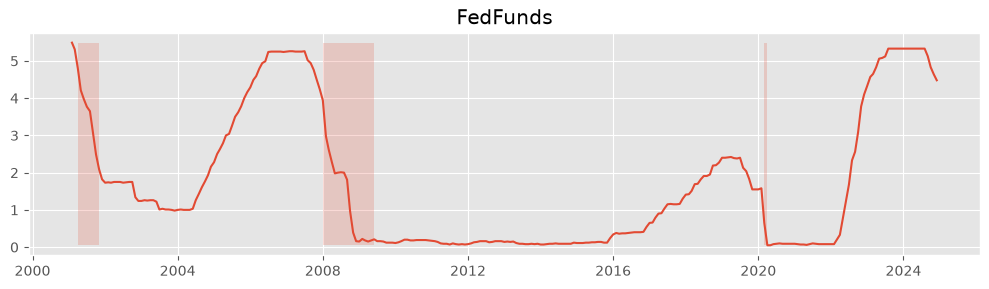

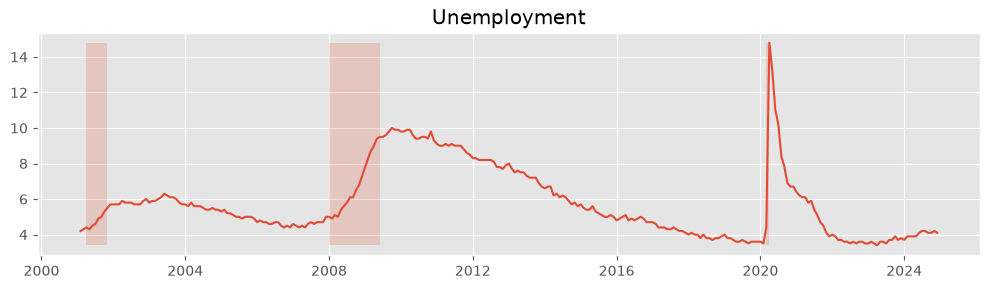

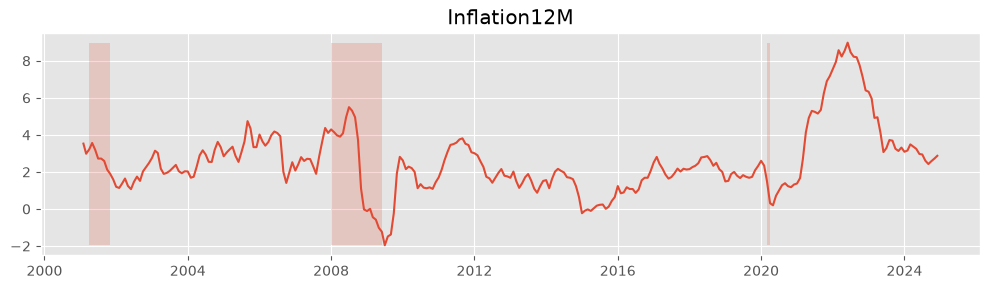

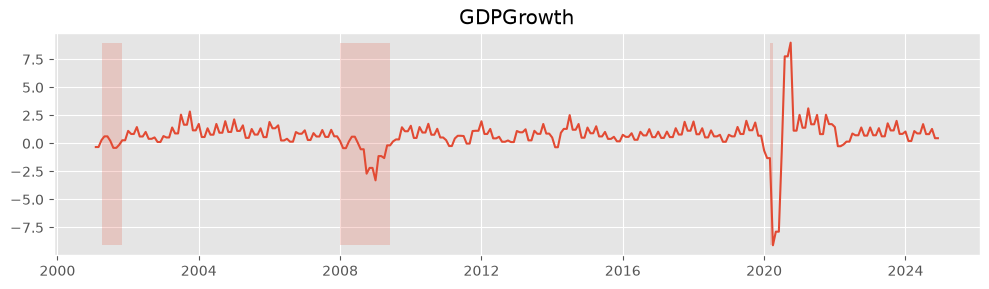

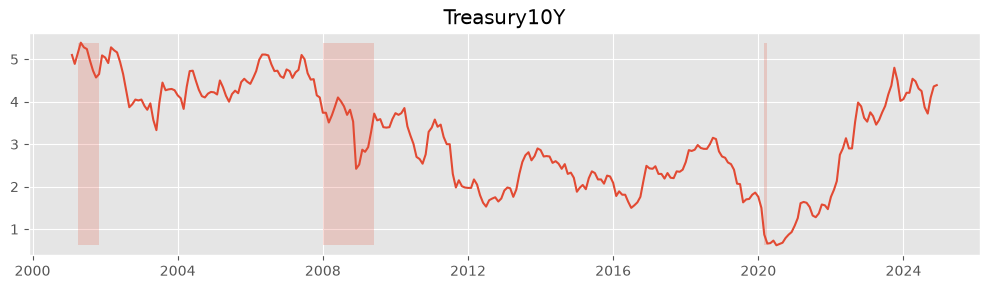

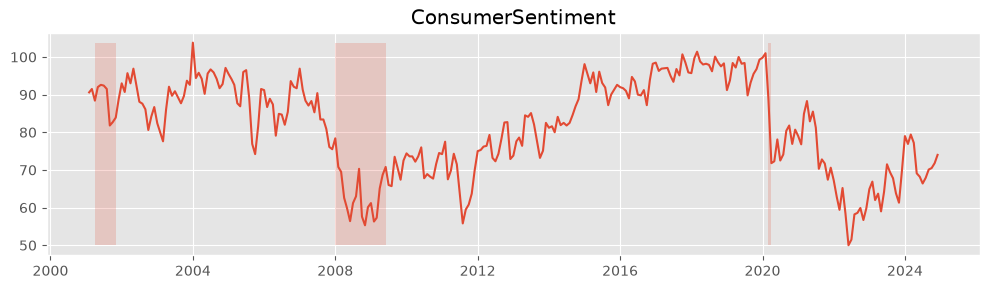

In [14]:

vars_to_plot = ["FedFunds","Unemployment","Inflation12M","GDPGrowth","Treasury10Y","ConsumerSentiment"]

for v in vars_to_plot:
    plt.figure(figsize=(10,3))
    plt.plot(df.index, df[v])
    plt.title(v)

    rec = df["Recession"].values
    plt.fill_between(df.index, df[v].min(), df[v].max(), where=rec==1, alpha=0.2)

    plt.tight_layout()
    plt.show()


## Correlation Matrix

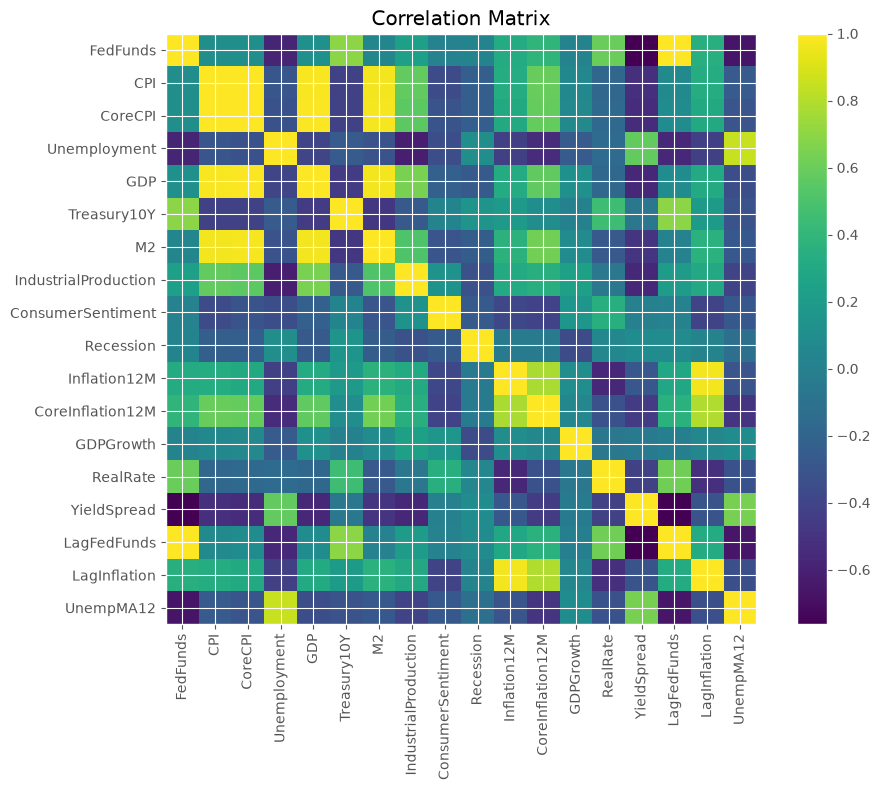

,FedFunds,CPI,CoreCPI,Unemployment,GDP,Treasury10Y,M2,IndustrialProduction,ConsumerSentiment,Recession,Inflation12M,CoreInflation12M,GDPGrowth,RealRate,YieldSpread,LagFedFunds,LagInflation,UnempMA12
FedFunds,1.00,0.11,0.12,-0.58,0.12,0.70,0.04,0.23,0.02,0.03,0.32,0.39,0.03,0.60,-0.76,0.99,0.35,-0.66
CPI,0.11,1.00,1.00,-0.29,0.98,-0.42,0.97,0.58,-0.35,-0.23,0.33,0.59,0.06,-0.18,-0.53,0.08,0.33,-0.26
CoreCPI,0.12,1.00,1.00,-0.32,0.99,-0.42,0.98,0.56,-0.31,-0.24,0.31,0.59,0.07,-0.16,-0.54,0.09,0.31,-0.30
Unemployment,-0.58,-0.29,-0.32,1.00,-0.39,-0.26,-0.31,-0.61,-0.34,0.11,-0.43,-0.54,-0.26,-0.14,0.57,-0.56,-0.43,0.85
GDP,0.12,0.98,0.99,-0.39,1.00,-0.45,0.97,0.65,-0.22,-0.26,0.32,0.57,0.12,-0.17,-0.57,0.09,0.31,-0.34
Treasury10Y,0.70,-0.42,-0.42,-0.26,-0.45,1.00,-0.47,-0.27,0.03,0.15,0.18,0.10,0.01,0.45,-0.07,0.70,0.20,-0.31
M2,0.04,0.97,0.98,-0.31,0.97,-0.47,1.00,0.52,-0.30,-0.24,0.37,0.63,0.09,-0.27,-0.49,0.02,0.36,-0.28
IndustrialProduction,0.23,0.58,0.56,-0.61,0.65,-0.27,0.52,1.00,0.14,-0.32,0.31,0.34,0.24,-0.07,-0.56,0.21,0.30,-0.40
ConsumerSentiment,0.02,-0.35,-0.31,-0.34,-0.22,0.03,-0.30,0.14,1.00,-0.26,-0.38,-0.41,0.16,0.34,0.00,0.02,-0.40,-0.28
Recession,0.03,-0.23,-0.24,0.11,-0.26,0.15,-0.24,-0.32,-0.26,1.00,-0.03,-0.04,-0.36,0.05,0.09,0.08,0.02,-0.11


In [15]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

corr.round(2)


## Hypothesis Testing

In [16]:

r, p = pearsonr(df["FedFunds"], df["Unemployment"])
print("Fed Funds vs Unemployment:", r, p)

t, p2 = ttest_ind(
    df[df["Recession"]==1]["ConsumerSentiment"],
    df[df["Recession"]==0]["ConsumerSentiment"],
    equal_var=False
)

print("Recession vs Sentiment:", t, p2)


Fed Funds vs Unemployment: -0.5811239178452412 2.5514294948854378e-27
Recession vs Sentiment: -4.325358209899199 0.00013804532932216573


## Regression Model

In [17]:

X = df[["FedFunds","Inflation12M","GDPGrowth","YieldSpread","ConsumerSentiment","IndustrialProduction"]]
y = df["Unemployment"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           Unemployment   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     129.1
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           1.27e-77
Time:                        13:20:40   Log-Likelihood:                -411.09
No. Observations:                 287   AIC:                             836.2
Df Residuals:                     280   BIC:                             861.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   27.3725 

## Machine Learning Model

R2: 0.9413431956460717


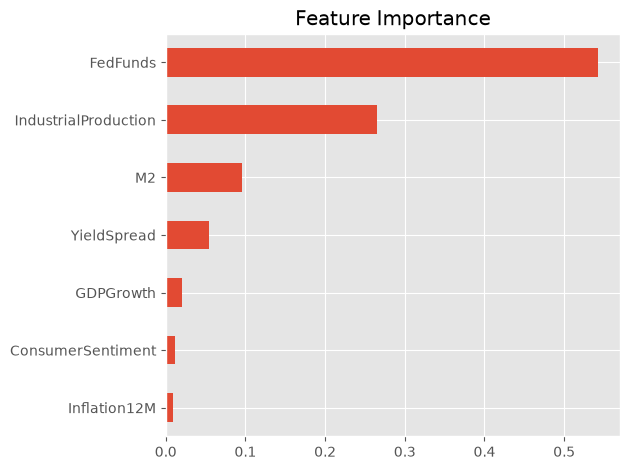

In [18]:

features = df[["FedFunds","Inflation12M","GDPGrowth","YieldSpread","M2","IndustrialProduction","ConsumerSentiment"]]
target = df["Unemployment"]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R2:", r2_score(y_test, pred))

imp = pd.Series(rf.feature_importances_, index=features.columns).sort_values()
imp.plot(kind="barh", title="Feature Importance")
plt.tight_layout()
plt.show()


### [1] Dataset Summary

This project uses a macroeconomic dataset constructed from the Federal Reserve Economic Data (FRED) database. The dataset contains 300 monthly observations spanning January 2000 to December 2024, capturing multiple phases of the U.S. business cycle, including the 2001 recession, the 2008 financial crisis, the COVID-19 recession, and the post-pandemic inflation period.

The dataset includes the following 10 macroeconomic variables:

* Federal Funds Rate (monetary policy instrument)
* Consumer Price Index (CPI) (inflation measure)
* Core CPI (inflation excluding food and energy)
* Unemployment Rate (labor market condition)
* Real GDP (economic output)
* 10-Year Treasury Yield (long-term interest rates)
* M2 Money Supply (liquidity in the economy)
* Industrial Production (real economic activity)
* Consumer Sentiment (household expectations)
* Recession Indicator (binary variable identifying NBER recessions)


Target Variable

For analysis and modeling purposes, the primary target variable is the Unemployment Rate, as it is a central indicator of macroeconomic health and is influenced by monetary policy, inflation, and economic growth conditions.

Key Characteristics of the Dataset
* 300 observations (monthly frequency)
* No missing values after forward-filling macro series
* Mix of level variables (CPI, GDP) and rate variables (Fed Funds, unemployment)
* Includes both cyclical and structural macroeconomic indicators

### [2] Data Exploration Plan

The goal of this analysis is to understand how monetary policy, inflation, financial conditions, and real economic activity interact over time and how they jointly influence labor market outcomes.

The exploration plan is structured as follows:

1. Data Understanding
    * Examine distributions, summary statistics, and time coverage
    * Identify economic meaning of each variable
2. Time-Series Exploration
    * Plot each macroeconomic variable over time
    * Identify business cycle patterns and recession periods
    * Compare cyclical vs structural variables
3. Relationship Analysis
    * Correlation matrix between macro variables
    * Scatter plots between key economic relationships:
    * Fed Funds vs Unemployment
    * Inflation vs Interest Rates
    * GDP Growth vs Unemployment
4. Feature Engineering
    * Construct economically meaningful variables:
    * Inflation rates (12-month change)
    * GDP growth rates
    * Real interest rates
    * Yield spreads
    * Lagged monetary policy variables
5. Statistical Testing
Test relationships using:
    * Correlation tests
    * t-tests (recession vs expansion periods)
    * Regression analysis
6. Predictive Modeling
    * Prepare dataset for machine learning
    * Predict unemployment using macroeconomic indicators

### [3] Exploratory Data Analysis (EDA)

The exploratory analysis reveals several important macroeconomic patterns.

1. Business Cycle Dynamics

Time-series plots show clear cyclical behavior:

* Unemployment rises sharply during recessions (2008, 2020)
* Industrial production declines during economic contractions
* Consumer sentiment falls significantly during crises

This confirms that the dataset successfully captures real business cycle fluctuations.

2. Monetary Policy Behavior

The Federal Funds Rate responds strongly to macroeconomic conditions:

* Rates fall during recessions (stimulus periods)
* Rates rise during inflationary periods (tightening cycles)
* The 2008–2015 and 2020–2021 periods show prolonged near-zero interest rates

This aligns with standard Federal Reserve policy behavior.

3. Inflation Dynamics
* CPI shows a persistent upward trend (price level growth)
* Core CPI is smoother and less volatile than headline CPI
* Inflation accelerates significantly post-2020

This reflects supply shocks and demand recovery after COVID-19.

4. Financial Conditions

* Treasury yields and Fed Funds Rate move together over time
* Yield spreads contain information about economic conditions
* Money supply (M2) expands significantly during crisis periods

5. Correlation Structure

Key relationships observed:

* Negative relationship between GDP growth and unemployment
* Positive relationship between Fed Funds Rate and inflation (with lag effects)
* Strong link between consumer sentiment and recession periods

### [4] Data Cleaning & Feature Engineering
##### Data Cleaning Steps

The dataset required minimal cleaning because FRED data is high quality and pre-validated. The following steps were applied:

* Missing values were handled using forward-fill interpolation, especially for macro series released at different frequencies (e.g., GDP quarterly data)
* All variables were aligned to a consistent monthly frequency
* The recession indicator was treated as a binary variable (0 = expansion, 1 = recession)
##### Feature Engineering

To improve economic interpretability, several new variables were created:

1. Inflation Measures
    * 12-month CPI inflation rate
    * 12-month Core CPI inflation rate
2. Economic Growth
    * Quarterly GDP growth rate (annualized proxy)
3. Financial Conditions
    * Real Interest Rate = Fed Funds Rate − Inflation
    * Yield Spread = 10-Year Treasury − Fed Funds Rate
4. Lagged Effects
    * Lagged Fed Funds Rate (monetary policy delay effect)
    * Lagged Inflation (expectation formation)
5. Smoothing Variables
    * 12-month moving average unemployment rate

##### Why Feature Engineering Matters

These transformations are important because macroeconomic relationships are rarely instantaneous. For example:

* Monetary policy affects unemployment with a lag
* Inflation expectations adjust slowly over time
* Growth rates are more informative than raw levels
    
### [5] Key Findings & Insights

The analysis produces several economically meaningful insights:

1. Monetary Policy is Cyclical

    Interest rates respond strongly to macroeconomic conditions, rising during inflationary periods and falling during recessions.

2. Labor Markets are Highly Cyclical

    Unemployment is the most responsive variable to economic downturns, making it a strong target variable for prediction.

3. Inflation is Persistent

    Inflation trends upward over time and reacts slowly to policy interventions, consistent with economic theory.

4. Financial Markets Lead the Economy

    Yield spreads and sentiment variables often move before changes in unemployment and GDP.

5. Recessions Affect All Variables Simultaneously

    During recessions:

    * GDP falls
    * unemployment rises
    * sentiment collapses
    * interest rates decline

    This confirms strong macroeconomic co-movement.

### [6] Hypothesis Formulation

Three hypotheses are tested:

##### Hypothesis 1 (Monetary Policy & Labor Markets)

Higher Federal Funds Rates are associated with higher unemployment.

##### Hypothesis 2 (Output & Labor Markets)

Higher GDP growth is associated with lower unemployment.

##### Hypothesis 3 (Business Cycles & Sentiment)

Consumer sentiment is significantly lower during recession periods compared to expansion periods.

### [7] Hypothesis Testing & Significance Analysis
##### Test 1: Fed Funds Rate vs Unemployment (Correlation Test)
* Null Hypothesis (H0): No relationship exists between interest rates and unemployment
* Alternative Hypothesis (H1): A relationship exists

A Pearson correlation test is applied to measure the linear relationship.

##### Interpretation:
A positive correlation would suggest that tighter monetary policy is associated with weaker labor market conditions, although causality cannot be inferred directly.

##### Test 2: Consumer Sentiment (t-test)

We compare average consumer sentiment during recession vs expansion periods using an independent samples t-test.

* H0: No difference in sentiment between recessions and expansions
* H1: Sentiment is lower during recessions

##### Interpretation:
A statistically significant negative difference would confirm that households are highly sensitive to macroeconomic downturns.

##### Economic Interpretation

Even if some relationships are statistically weak, they may still be economically meaningful due to:

Lagged effects of monetary policy
Structural breaks (e.g., COVID period)
Endogeneity in macroeconomic systems
### [8] Conclusion & Next Steps
##### Conclusion

This project demonstrates how macroeconomic data can be transformed into a structured analytical framework that combines:

* Economic theory
* Statistical inference
* Data visualization
* Machine learning

Key takeaway: macroeconomic variables are highly interconnected, and business cycle dynamics strongly influence all major indicators simultaneously.

Next Steps 

To extend this project further, the following improvements would be natural:

1. Econometric Extensions
    * Vector Autoregression (VAR) model
    * Granger causality tests
    * Impulse response functions (Fed shock → unemployment)
2. Forecasting Models
    * ARIMA for inflation or unemployment
    * Time-series forecasting with lag structure
3. Advanced Machine Learning
    * Gradient boosting models
    * Feature selection using SHAP values
    * Time-series cross-validation
4. Policy Interpretation
    * Translate results into Federal Reserve-style policy memo
    * Discuss implications for interest rate decisions
